In [24]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [25]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [26]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

REMOVE WRONG IMAGE FILES

In [27]:
import cv2
import imghdr

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
data_dir = "/content/drive/MyDrive/Drugdatasets"

In [30]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [31]:
from PIL import Image
import os

for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)

    for image in os.listdir(class_path):
        image_path = os.path.join(class_path, image)

        try:
            img = Image.open(image_path)
            img.verify()  # verify image integrity

        except Exception:
            print(f"Corrupted image: {image_path}")
            os.remove(image_path)

LOADING DATASETS

In [32]:
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=True
)

print('Classes:', data.class_names)

class_names = data.class_names


Found 1395 files belonging to 3 classes.
Classes: ['fake', 'non-drug', 'real']


In [33]:
data = data.map(lambda x, y: (preprocess_input(x), y))

In [34]:
train_size = int(len(data)*0.7)
val_size = int(len(data)*0.2)
test_size = int(len(data)*0.1)

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

DATA AUGMENTATION

In [35]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

train = train.map(lambda x, y: (data_augmentation(x), y))

In [36]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,790 (16.83 MB)

 Trainable params: 361,219 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

COMPILE MODEL

In [37]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


CALLBACKS

In [38]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3
)

In [39]:
history = model.fit(
    train,
    validation_data=val,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7396 - loss: 0.6366 - val_accuracy: 0.8789 - val_loss: 0.2895 - learning_rate: 0.0010
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8958 - loss: 0.3143 - val_accuracy: 0.9453 - val_loss: 0.1428 - learning_rate: 0.0010
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9135 - loss: 0.2341 - val_accuracy: 0.9336 - val_loss: 0.1765 - learning_rate: 0.0010
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9365 - loss: 0.1950 - val_accuracy: 0.9531 - val_loss: 0.1574 - learning_rate: 0.0010
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9448 - loss: 0.1460 - val_accuracy: 0.9453 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9604 - loss: 0.1064 - val_accuracy: 0.9531 - val_loss: 0.1355 - learning_rate: 2.0000e-04
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.9635 - loss: 0.1021 - val_accura

FINE TUNING

In [40]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train,
    validation_data=val,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7135 - loss: 0.7927 - val_accuracy: 0.9531 - val_loss: 0.1540 - learning_rate: 1.0000e-05
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.7979 - loss: 0.5521 - val_accuracy: 0.9062 - val_loss: 0.2515 - learning_rate: 1.0000e-05
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8417 - loss: 0.4061 - val_accuracy: 0.9023 - val_loss: 0.2508 - learning_rate: 1.0000e-05
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8573 - loss: 0.3973 - val_accuracy: 0.8984 - val_loss: 0.2387 - learning_rate: 2.0000e-06
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8615 - loss: 0.3664 - val_accuracy: 0.8867 - val_loss: 0.2669 - learning_rate: 2.0000e-06


PLOT

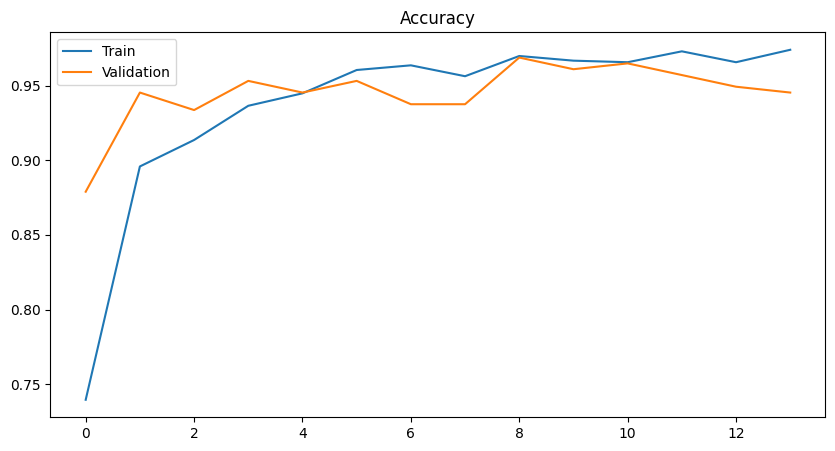

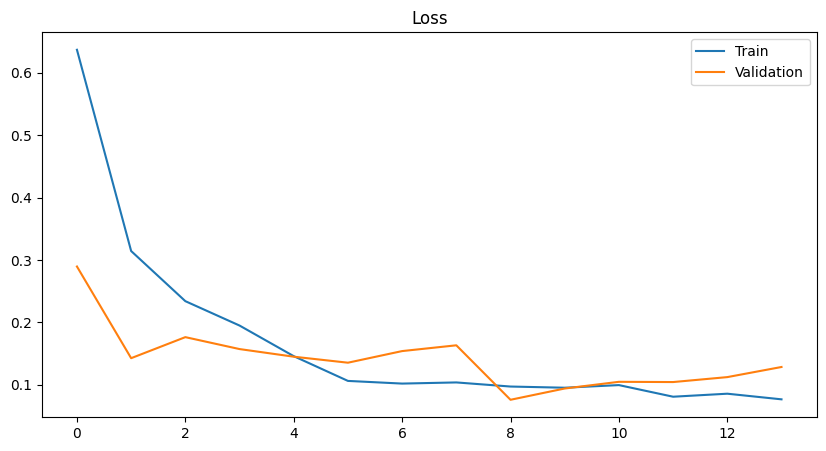

In [41]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy')
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title('Loss')
plt.show()

In [42]:
y_true = []
y_pred = []

for images, labels in test:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

print(confusion_matrix(y_true, y_pred))

              precision    recall  f1-score   support

        fake       0.85      0.97      0.91        30
    non-drug       0.98      1.00      0.99        43
        real       0.98      0.89      0.93        55

    accuracy                           0.95       128
   macro avg       0.94      0.95      0.94       128
weighted avg       0.95      0.95      0.95       128

[[29  0  1]
 [ 0 43  0]
 [ 5  1 49]]


In [43]:
loss, acc = model.evaluate(val)
print("Accuracy:", acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 279ms/step - accuracy: 0.9453 - loss: 0.1571
Accuracy: 0.9453125


In [44]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

        fake       0.85      0.97      0.91        30
    non-drug       0.98      1.00      0.99        43
        real       0.98      0.89      0.93        55

    accuracy                           0.95       128
   macro avg       0.94      0.95      0.94       128
weighted avg       0.95      0.95      0.95       128



SAVING MODEL

In [46]:
model.save('counterfeit_drug_detector_cnn.keras')

In [61]:
# Predict New Image

image_path = '/content/08-Paracetamol-96-WorldCup-Pack-View-01-844x1024.png'

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = tf.image.resize(img,(224,224))
img = img/255.0

img = np.expand_dims(img, axis=0)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print('Prediction:', class_names[predicted_class])
print('Confidence:', np.max(prediction))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Prediction: fake
Confidence: 0.47862077


In [65]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/counterfeit_drug_detector_cnn.keras'
)

In [79]:
img = tf.keras.utils.load_img(
    '/content/IMG_20260521_120156.jpg',
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [80]:
predictions = model.predict(img_array)

predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: real
Confidence: 0.8596164
